In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import os
import shutil
import random

# Đường dẫn dataset gốc
base_path = r"archive"

cat_dir = os.path.join(base_path, "cats_set")
dog_dir = os.path.join(base_path, "dogs_set")

# Đường dẫn dataset sau khi tách train/val
output_base = r"dataset_split"

train_cat = os.path.join(output_base, "train", "cats")
train_dog = os.path.join(output_base, "train", "dogs")
val_cat   = os.path.join(output_base, "val", "cats")
val_dog   = os.path.join(output_base, "val", "dogs")

# Tạo thư mục nếu chưa có
for d in [train_cat, train_dog, val_cat, val_dog]:
    os.makedirs(d, exist_ok=True)

# Lấy danh sách ảnh
cat_images = os.listdir(cat_dir)
dog_images = os.listdir(dog_dir)

random.shuffle(cat_images)
random.shuffle(dog_images)

# Tỉ lệ train/val: 80% train – 20% val
split_ratio = 0.8

cat_split = int(len(cat_images) * split_ratio)
dog_split = int(len(dog_images) * split_ratio)

train_cats = cat_images[:cat_split]
val_cats   = cat_images[cat_split:]

train_dogs = dog_images[:dog_split]
val_dogs   = dog_images[dog_split:]

# ---------------------------
# Hàm copy ảnh hỗ trợ
# ---------------------------
def copy_images(img_list, src_folder, dst_folder):
    for img in img_list:
        src = os.path.join(src_folder, img)
        dst = os.path.join(dst_folder, img)

        # Tránh lỗi nếu ảnh hỏng hoặc bị khóa
        try:
            shutil.copy(src, dst)
        except:
            print("Cannot copy:", src)

# Copy vào thư mục train / val
copy_images(train_cats, cat_dir, train_cat)
copy_images(val_cats,   cat_dir, val_cat)

copy_images(train_dogs, dog_dir, train_dog)
copy_images(val_dogs,   dog_dir, val_dog)

print("DONE! Dataset đã được tách thành train/val.")


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framewo

DONE! Dataset đã được tách thành train/val.


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Đường dẫn dataset đã tách train/val
dataset_base = r"dataset_split"

train_dir = os.path.join(dataset_base, "train")
val_dir   = os.path.join(dataset_base, "val")

# -----------------------------
# Data Augmentation cho tập train
# -----------------------------
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation không dùng augmentation
val_gen = ImageDataGenerator(rescale=1./255)

# -----------------------------
# Load data từ thư mục train/
# -----------------------------
train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(150,150),     # resize
    batch_size=32,
    class_mode='binary'
)

# -----------------------------
# Load data từ thư mục val/
# -----------------------------
val_data = val_gen.flow_from_directory(
    val_dir,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)


Found 999 images belonging to 2 classes.
Found 596 images belonging to 2 classes.


In [3]:
model = models.Sequential([
    layers.Conv2D(32,(3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       4,735,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

C:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 29s 851ms/step - accuracy: 0.4885 - loss: 0.7455 - val_accuracy: 0.5185 - val_loss: 0.6930
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 513ms/step - accuracy: 0.5135 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.6912
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 491ms/step - accuracy: 0.5085 - loss: 0.6947 - val_accuracy: 0.6023 - val_loss: 0.6849
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 473ms/step - accuracy: 0.5786 - loss: 0.6767 - val_accuracy: 0.5352 - val_loss: 0.6978
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 642ms/step - accuracy: 0.5626 - loss: 0.6837 - val_accuracy: 0.5621 - val_loss: 0.6738
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 781ms/step - accuracy: 0.5916 - loss: 0.6708 - val_accuracy: 0.5856 - val_loss: 0.6561
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 478ms/step - accuracy: 0.5946 - loss: 0.6660 - val_accuracy: 0.5923 - val_loss: 0.6734
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 469ms/step - accuracy: 0.5796 - loss: 0.6787 - val_accu

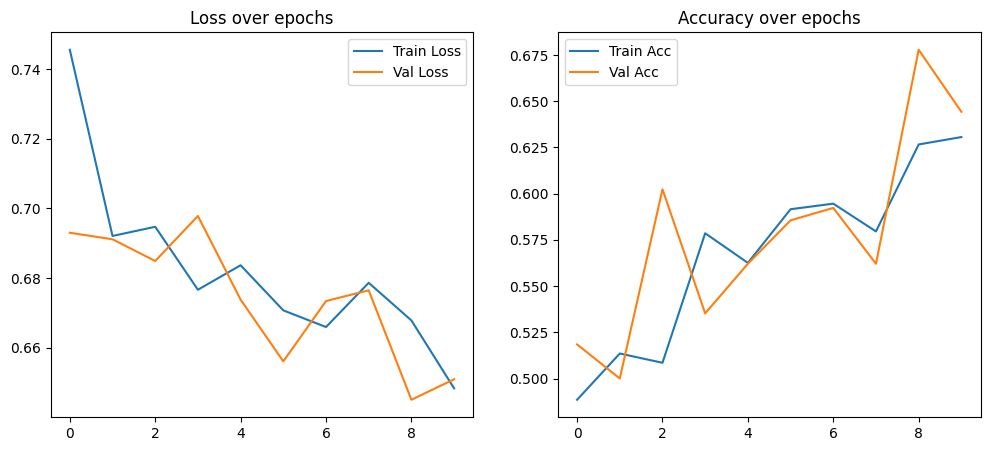

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.6443 - loss: 0.6510
Validation Accuracy: 0.6442952752113342


In [4]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss over epochs")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy over epochs")

plt.show()

loss, acc = model.evaluate(val_data)
print("Validation Accuracy:", acc)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


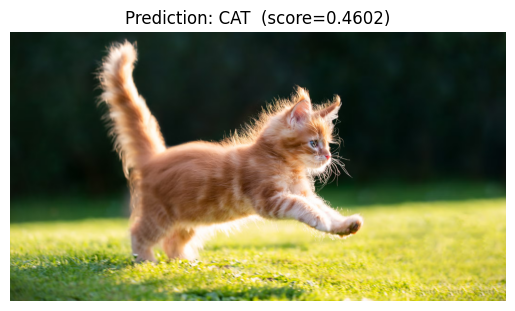

'CAT'

In [6]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_image(model, img_path):
    # Load ảnh và resize
    img = image.load_img(img_path, target_size=(150,150))
    
    # Chuyển sang mảng numpy
    x = image.img_to_array(img)
    x = x / 255.0             # chuẩn hóa
    x = np.expand_dims(x, 0)  # thêm batch dimension

    # Dự đoán
    pred = model.predict(x)[0][0]

    # Gán nhãn
    label = "DOG" if pred > 0.5 else "CAT"

    # Hiển thị ảnh và kết quả
    plt.imshow(image.load_img(img_path))
    plt.title(f"Prediction: {label}  (score={pred:.4f})")
    plt.axis("off")
    plt.show()

    return label

img_path = r"test_image.jpg"
predict_image(model, img_path)
